In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# defining dataset directory
test_dir = "/content/drive/MyDrive/AI Ml folder/FruitinAmazon/test"
train_dir = "/content/drive/MyDrive/AI Ml folder/FruitinAmazon/train"

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np

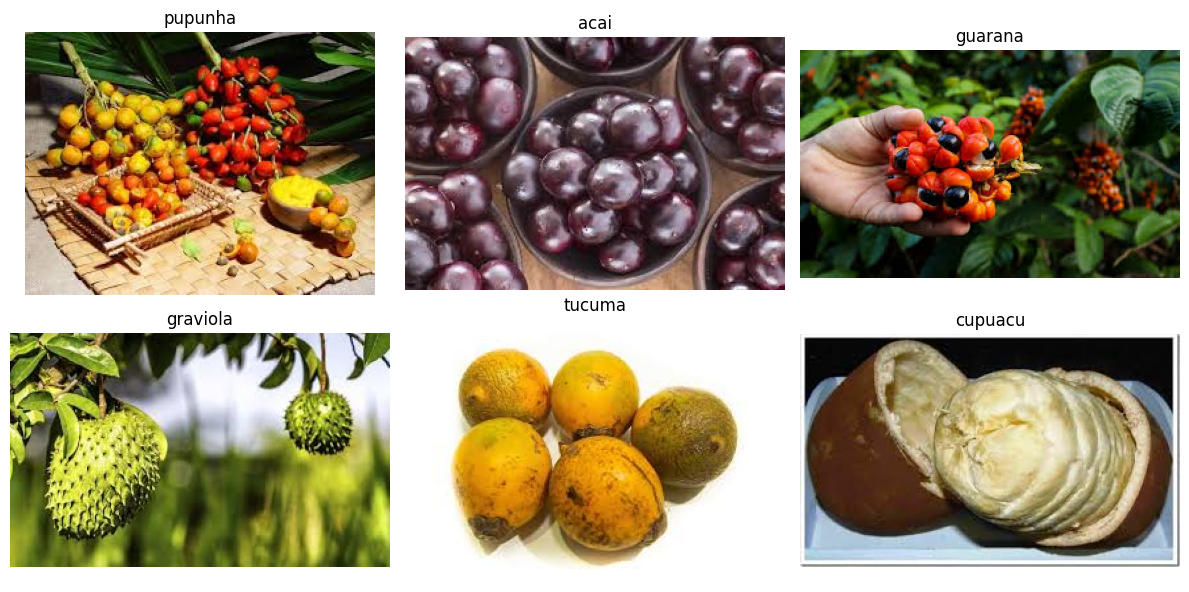

In [ ]:
import os
import random
import cv2
import matplotlib.pyplot as plt

# Path to your training directory
train_dir = "/content/drive/MyDrive/AI Ml folder/FruitinAmazon/train"

# Get class directories
classes = [cls for cls in os.listdir(train_dir)
           if os.path.isdir(os.path.join(train_dir, cls))]

# Select one random image from each class
images = []
labels = []

for cls in classes:
    class_path = os.path.join(train_dir, cls)

    files = os.listdir(class_path)
    if len(files) == 0:
        continue

    img_file = random.choice(files)
    img_path = os.path.join(class_path, img_file)

    img = cv2.imread(img_path)
    if img is None:
        continue

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # convert for matplotlib

    images.append(img)
    labels.append(cls)

# Display in grid (2 rows)
num_images = len(images)
cols = (num_images + 1) // 2  # calculate columns for 2 rows

plt.figure(figsize=(12, 6))

for i in range(num_images):
    plt.subplot(2, cols, i + 1)
    plt.imshow(images[i])
    plt.title(labels[i])
    plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
import os
from PIL import Image

# Path to your dataset
train_dir = "/content/drive/MyDrive/AI Ml folder/FruitinAmazon/train"

corrupted_images = []

# Iterate through each class folder
for class_name in os.listdir(train_dir):
    class_path = os.path.join(train_dir, class_name)

    if not os.path.isdir(class_path):
        continue

    for filename in os.listdir(class_path):
        image_path = os.path.join(class_path, filename)

        try:
            # Try opening and verifying the image
            with Image.open(image_path) as img:
                img.verify()  # checks if image is broken

        except (IOError, SyntaxError):
            # If corrupted → remove it
            corrupted_images.append(image_path)
            os.remove(image_path)
            print(f"Removed corrupted image: {image_path}")

# Final report
print("\nTotal corrupted images removed:", len(corrupted_images))


Total corrupted images removed: 0


In [ ]:
import tensorflow as tf
# Define image size and batch size
img_height = 128 # Example image height
img_width = 128 # Example image width
batch_size = 32
validation_split = 0.2 # 80% training, 20% validation
# Create a preprocessing layer for normalization
rescale = tf.keras.layers.Rescaling(1./255) # Normalize pixel values to [0, 1]
# Create training dataset with normalization
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
train_dir,
labels='inferred',
label_mode='int',
image_size=(img_height, img_width),
interpolation='nearest',
batch_size=batch_size,
shuffle=True,
validation_split=validation_split,
subset='training',
seed=123
)
# Apply the normalization (Rescaling) to the dataset
train_ds = train_ds.map(lambda x, y: (rescale(x), y))
# Create validation dataset with normalization
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
train_dir,
labels='inferred',
label_mode='int',
image_size=(img_height, img_width),
interpolation='nearest',
batch_size=batch_size,
shuffle=False,
validation_split=validation_split,
subset='validation',
seed=123
)
# Apply the normalization (Rescaling) to the validation dataset
val_ds = val_ds.map(lambda x, y: (rescale(x), y))

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.


In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# This is a sample implementation, Thus I only use two augmentation, you can use more than two
# augmentation type for your project. Please check keras documentations for other available
# augmentation techniques.
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
])

In [ ]:
augmented_train_ds = train_ds.map( lambda x, y: (data_augmentation(x, training=True), y))

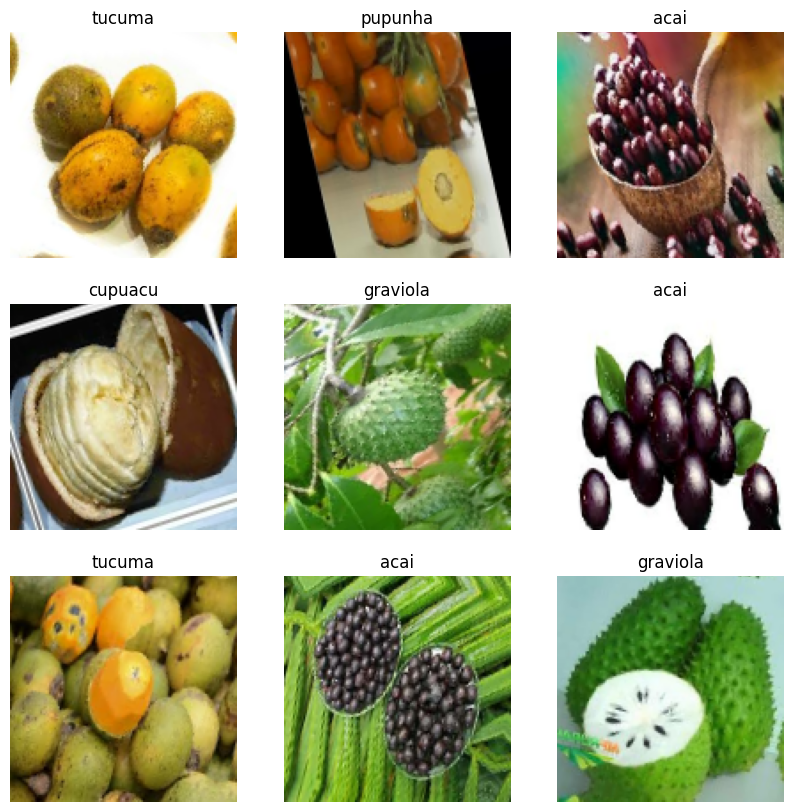

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))
for images, labels in augmented_train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1);
        # Scale pixel values back to 0-255 for proper display with uint8
        plt.imshow((images[i].numpy() * 255).astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")
plt.show()

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np

# Get the number of classes from the dataset using the globally defined class_names variable
num_classes = len(class_names) # Corrected to use the global 'class_names' list

# Define a simple CNN model
model = keras.Sequential([
    layers.Conv2D(32, (3, 3), activation="relu", input_shape=(img_height, img_width, 3)), # Corrected input_shape
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dense(num_classes, activation="softmax") # Corrected number of classes
])

# Compile the model
model.compile(optimizer="adam",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

# Train the model using the tf.data.Dataset objects
model.fit(augmented_train_ds, epochs=5, validation_data=val_ds)

# Evaluate the model
test_loss, test_acc = model.evaluate(val_ds) # Using val_ds for evaluation as test_ds is not defined
print(f"Test accuracy: {test_acc:.4f}")

# Make predictions on a batch from the validation dataset
for images, labels in val_ds.take(1):
    predictions = model.predict(images)
    predicted_labels = np.argmax(predictions, axis=1)
    print("Predicted labels:", predicted_labels)
    print("Actual labels: ", labels.numpy())


Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 448ms/step - accuracy: 0.1389 - loss: 3.3499 - val_accuracy: 0.0000e+00 - val_loss: 1.8910
Epoch 2/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 481ms/step - accuracy: 0.2639 - loss: 2.1141 - val_accuracy: 0.2222 - val_loss: 1.5814
Epoch 3/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 472ms/step - accuracy: 0.4028 - loss: 1.6070 - val_accuracy: 0.2222 - val_loss: 1.6189
Epoch 4/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 382ms/step - accuracy: 0.3472 - loss: 1.4985 - val_accuracy: 0.7222 - val_loss: 1.5058
Epoch 5/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 389ms/step - accuracy: 0.5694 - loss: 1.3335 - val_accuracy: 0.7222 - val_loss: 1.4164
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step - accuracy: 0.7222 - loss: 1.4164
Test accuracy: 0.7222
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step
Predicted labels: [5 0 3 5 5 5 5 5 5 5 0 5 5 5 1 5 5 5]
Actual labels:  [4 4 4 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5]


In [ ]:
from tensorflow.keras.applications import VGG16

# Load the VGG16 model pre-trained on ImageNet, without the top classification layer
# Using img_height and img_width from previous cells, and 3 channels for RGB images.
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(img_height, img_width, 3))

In [ ]:
# Freeze the layers of the base model
for layer in base_model.layers:
    layer.trainable = False

In [ ]:
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D

# Add custom layers on top of the pre-trained model
x = base_model.output
x = GlobalAveragePooling2D()(x) # Reduces dimensions (height, width) to a single vector per image
x = Dense(1024, activation='relu')(x) # Fully connected layer with 1024 neurons
x = Dense(num_classes, activation='softmax') (x) # Output layer for 'num_classes' (6) with softmax

In [ ]:
from tensorflow.keras.models import Model

# Create the full model by connecting the base_model input to the custom layers' output (x)
transfer_model = Model(inputs=base_model.input, outputs=x)

In [ ]:
from tensorflow.keras.optimizers import Adam

# Compile the model
transfer_model.compile(optimizer=Adam(), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train the model
# Using augmented_train_ds and val_ds as defined previously
history = transfer_model.fit(
    augmented_train_ds,
    epochs=20, # Starting with a reasonable number of epochs, can be adjusted
    validation_data=val_ds
)

Epoch 1/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 18s 6s/step - accuracy: 0.8333 - loss: 0.5836 - val_accuracy: 0.7778 - val_loss: 0.5366
Epoch 2/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 12s 4s/step - accuracy: 0.8611 - loss: 0.4766 - val_accuracy: 0.7222 - val_loss: 0.8643
Epoch 3/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 12s 4s/step - accuracy: 0.9306 - loss: 0.3975 - val_accuracy: 0.7778 - val_loss: 0.5414
Epoch 4/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 21s 4s/step - accuracy: 0.9444 - loss: 0.3573 - val_accuracy: 0.8333 - val_loss: 0.4092
Epoch 5/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 12s 3s/step - accuracy: 0.9583 - loss: 0.3172 - val_accuracy: 0.7778 - val_loss: 0.6060
Epoch 6/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 22s 4s/step - accuracy: 0.9444 - loss: 0.2778 - val_accuracy: 0.6667 - val_loss: 0.7820
Epoch 7/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 12s 4s/step - accuracy: 0.9444 - loss: 0.2785 - val_accuracy: 0.6667 - val_loss: 0.6499
Epoch 8/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 12s 4s/step - accuracy: 0.9861 - loss: 0.1953 - val_accuracy: 0.9444 - val_loss: 0.4773
Epoch 9/

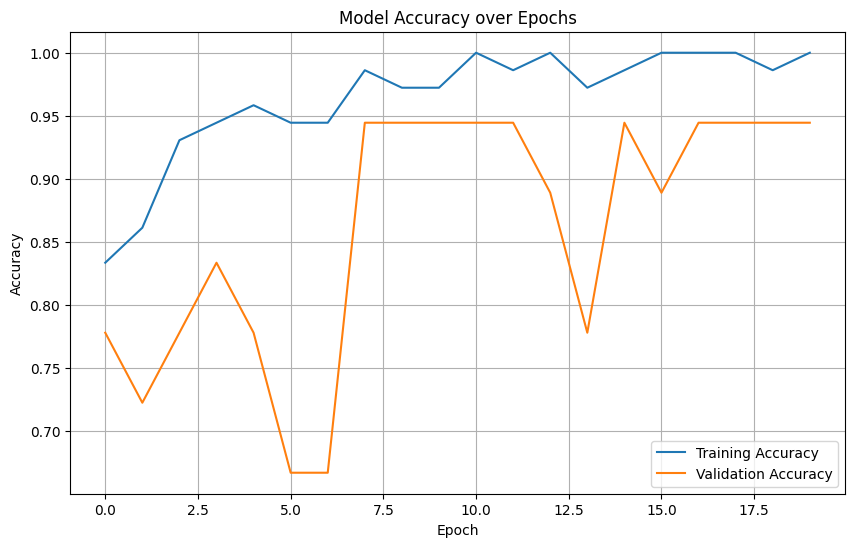

In [ ]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(10, 6))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy over Epochs')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

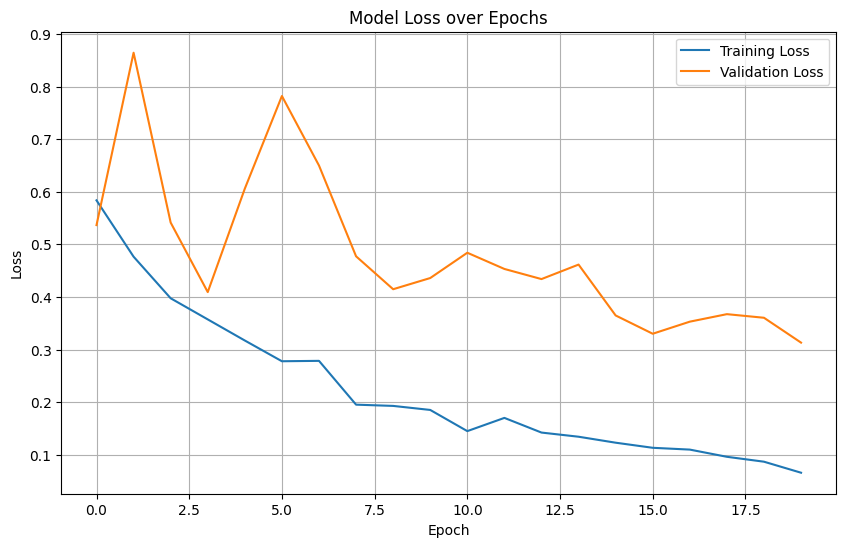

In [ ]:
# Plot training & validation loss values
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss over Epochs')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper right')
plt.grid(True)
plt.show()

In [ ]:
# Create test dataset with normalization
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=False # No need to shuffle test data
)

# Apply the normalization (Rescaling) to the test dataset
test_ds = test_ds.map(lambda x, y: (rescale(x), y))

Found 30 files belonging to 6 classes.


In [ ]:
from sklearn.metrics import classification_report
import numpy as np

# Evaluate the model on the test dataset
test_loss, test_accuracy = transfer_model.evaluate(test_ds)
print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

# Generate predictions for the classification report
test_labels = []
test_preds = []

for images, labels in test_ds:
    test_labels.extend(labels.numpy())
    predictions = transfer_model.predict(images)
    test_preds.extend(np.argmax(predictions, axis=1))

# Convert to numpy arrays
test_labels = np.array(test_labels)
test_preds = np.array(test_preds)

# Generate classification report
# Using the globally defined 'class_names' variable
report = classification_report(test_labels, test_preds, target_names=class_names, labels=np.arange(num_classes))
print("\nClassification Report for Test Set:")
print(report)

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - accuracy: 0.4667 - loss: 1.3902

Test Loss: 1.3902
Test Accuracy: 0.4667
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step

Classification Report for Test Set:
              precision    recall  f1-score   support

        acai       0.60      0.60      0.60         5
     cupuacu       0.33      0.20      0.25         5
    graviola       0.75      0.60      0.67         5
     guarana       0.67      0.80      0.73         5
     pupunha       0.25      0.20      0.22         5
      tucuma       0.25      0.40      0.31         5

    accuracy                           0.47        30
   macro avg       0.48      0.47      0.46        30
weighted avg       0.47      0.47      0.46        30

